In [1]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/D2-01_data-preprocessing.ipynb D2-01_data-preprocessing.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/D2-01_data-preprocessing.ipynb D2-01_data-preprocessing.ipynb


[NbConvertApp] Converting notebook D2-01_data-preprocessing.ipynb to notebook
[NbConvertApp] Writing 390353 bytes to ../exercises/D2-01_data-preprocessing.ipynb
[NbConvertApp] Converting notebook D2-01_data-preprocessing.ipynb to notebook
[NbConvertApp] Writing 492531 bytes to ../solutions/D2-01_data-preprocessing.ipynb


# Preprocessing data
In this notebook, we will prepare data from a file called `dataset_energy_preprocess.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

## Step 1: load data using the pandas library
Here we want to read the file form the file path, and then inspect the dataframe.

In [ ]:
file_path = f'{DATA_IN_PATH}/dataset_energy_preprocess.csv'
df_weather = pd.read_csv(file_path, index_col=0)
df_weather

,Pr,Tmin,v_max,Consumption_Household,Consumption_Total
2020-12-31 23:00:00,0.0,-0.4,2.4,565464.941,2040973.608
2021-01-01 00:00:00,0.0,-0.6,1.0,561738.679,2039950.800
2021-01-01 01:00:00,0.0,-1.1,1.3,552567.055,1982919.602
2021-01-01 02:00:00,0.0,-1.2,0.8,539974.014,1964304.053
2021-01-01 03:00:00,0.0,-1.5,1.5,530039.983,2005097.370
...,...,...,...,...,...
2025-09-16 17:00:00,2.1,12.9,1.8,368426.508,1689555.961
2025-09-16 18:00:00,0.0,12.8,2.3,382777.219,1607859.795
2025-09-16 19:00:00,0.0,12.4,2.2,381955.358,1536017.641
2025-09-16 20:00:00,0.0,12.4,3.6,362725.748,1489242.190


## Step 2: quality control
For quality control, we must first look at the data. The easiest way to spot problems is usually to plot the data and look for problem areas.
We first extract the data we need.

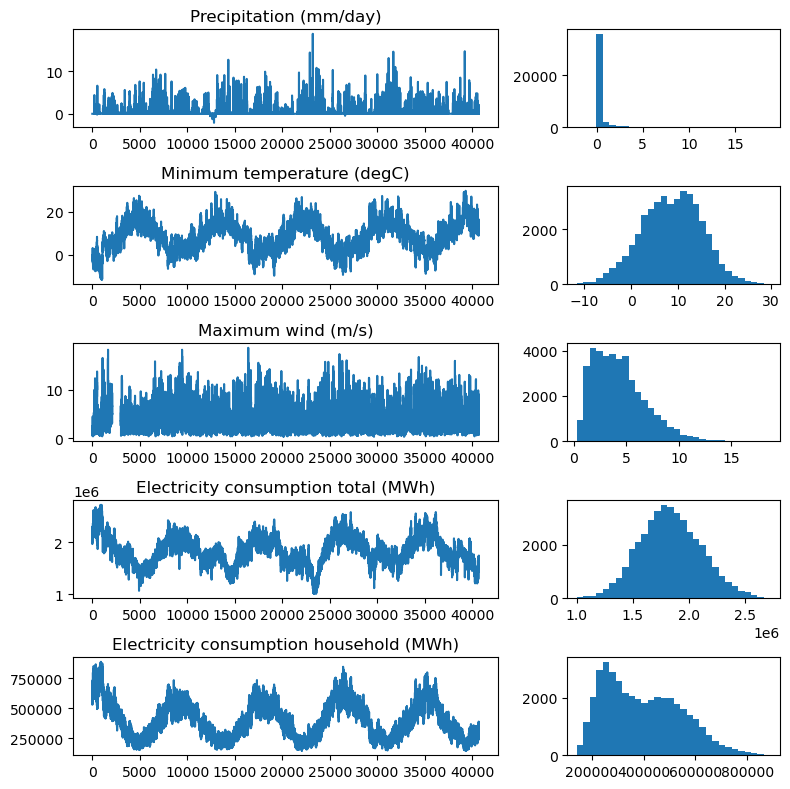

In [168]:
## Here we create a set of plots to look at a subset of our dataframe, selected into the dataset [df_weather]
fig, axs = plt.subplots(5,2,figsize=(8,8), width_ratios=[2,1])

axs[0,0].plot(df_weather.Pr.values)
axs[1,0].plot(df_weather.Tmin.values)
axs[2,0].plot(df_weather.v_max.values)
axs[3,0].plot(df_weather.Consumption_Total.values)
axs[4,0].plot(df_weather.Consumption_Household.values)
# axs[4,0].plot(df_weather.w_max.values)

axs[0,1].hist(df_weather.Pr.values, bins=30)

axs[1,1].hist(df_weather.Tmin.values, bins=30)
axs[2,1].hist(df_weather.v_max.values, bins=30)
axs[3,1].hist(df_weather.Consumption_Total.values, bins=30)
axs[4,1].hist(df_weather.Consumption_Household.values, bins=30)
# axs[4,1].hist(df_weather.w_max.values, bins=30)

axs[0,0].set_title('Precipitation (mm/day)')
axs[1,0].set_title('Minimum temperature (degC)')
axs[2,0].set_title('Maximum wind (m/s)')
axs[3,0].set_title('Electricity consumption total (MWh)')
axs[4,0].set_title('Electricity consumption household (MWh)')
# axs[4,0].set_title('Maximum wind (m/s)')

plt.tight_layout()

### Issues?

We can see that there are some strange and some missing values in our data. Can you spot them?

The distributions are also not what the ML models like. We will fix that a bit later.

### Only select data with good quality
Here we filter out missing data in four of our variables, and remove nonsensical data from a third.

In [169]:
qc_data_index = (df_weather.v_max.notnull() &
                 df_weather.Tmin.notnull()&
                 df_weather.Pr.notnull() &
                 df_weather.Consumption_Total.notnull() &
                 df_weather.Consumption_Household.notnull() &
                 (df_weather.Pr >= 0 ) )
df_weather_qc = df_weather.loc[qc_data_index]

## **QUESTION 1**: Compare the two datafames: `df_weather_extract_qc` and `df_weather_extract`
How can we compare the original dataset and our new, augmented one? How much data are we left with?

In [ ]:
print(...)
print(...)

In [170]:
print(df_weather.shape)
print(df_weather_qc.shape)

(40717, 5)
(39629, 5)


## Step 3: Reshaping the data
Up to this point, we have explored and 'cleaned' the data to make it better suited for analysis. 
The next step is to choose what we want to predict, our model output, and what we want to predict it based on, our features. 
In this example, we'll try to predict the two energy consumption time series based on the other selected variables above.

## **QUESTION 2**: Extract the variables wanted into `X` and `y` arrays

We want to predict `Consumption_Total` and `Consumption_Household` based on the other variables.

In [ ]:
X = df_weather_qc[[]].values ## In the inner brackets, select the features we want
y = df_weather_qc[].values ## In these brackets, select the desired output
print(X.shape, y.shape)

In [172]:
X = df_weather_qc[['Tmin','Pr','v_max']].values
y = df_weather_qc[['Consumption_Total', 'Consumption_Household']].values
print(X.shape, y.shape)

(39629, 3) (39629, 2)


Both `X` and `y` arrays should be in the shape `(n_samples, n_variables_per_sample)`. Is it the case?

## Step 4: Split into train, validation test



## **QUESTION 3**: Create train, validation and test datasets from `X`

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

In [173]:
X_train, X_valtest, y_train, y_valtest = sklearn.model_selection.train_test_split(X,y, train_size=0.7)
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(X_valtest, y_valtest, train_size=0.7)

## Step 5: Tranforming the data
The next step is to standardise the data into a shape our ML-algoritm understands.

In [175]:
## First, we import the standardisation functions we want from Scikit-learn
from sklearn.preprocessing import StandardScaler, PowerTransformer

## This next line lets us apply different transformation to each column
from sklearn.compose import ColumnTransformer 

### X Transform
Here, we use two transformers, `Standardize` on our temperature variable, and `Power transform` on our precipitation and wind variables.

In [176]:
preprocessor_X = ColumnTransformer(
    transformers=[('Standardize', StandardScaler(), [0]),
                  ('Power transform', PowerTransformer(standardize=True), [1,2]),
                  ])

preprocessor_X

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Standardize', ...), ('Power transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## **QUESTION 4**: Fit the `preprocessor_X` to the train dataset and transform the three `X` datasets

In [ ]:
...

X_train_transform = ...
X_val_transform = ...
X_test_transform = ...

In [179]:
preprocessor_X.fit(X_val)

X_train_transform = preprocessor_X.transform(X_train)
X_val_transform = preprocessor_X.transform(X_val)
X_test_transform = preprocessor_X.transform(X_test)

### y Transform
Here we use the transformer `PowerTransformer` on our predicted consumption data.

In [180]:
preprocessor_y = PowerTransformer()

preprocessor_y

,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True


## **QUESTION 5**: Fit the `preprocessor_y` to the train dataset and transform the three `y` datasets

In [ ]:
...

y_train_transform = ...
y_val_transform = ...
y_test_transform = ...

In [181]:
preprocessor_y.fit(y_val)

y_train_transform = preprocessor_y.transform(y_train)
y_val_transform = preprocessor_y.transform(y_val)
y_test_transform = preprocessor_y.transform(y_test)

### Plot the transformed dat

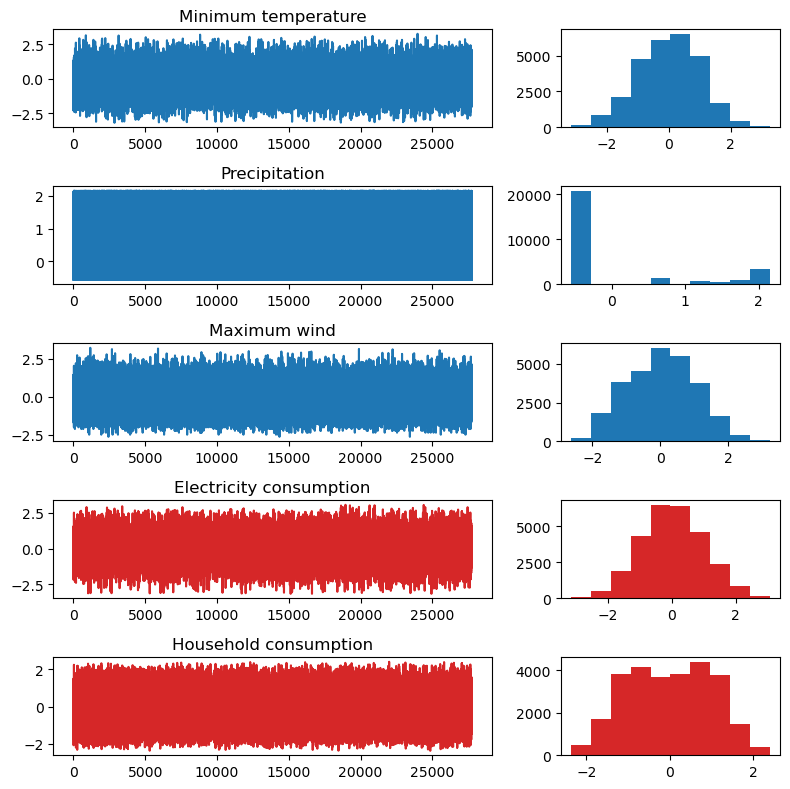

In [182]:
## Now we plot our newly transformed data!

fig, axs = plt.subplots(5,2,figsize=(8,8), width_ratios=[2,1])

axs[0,0].plot(X_train_transform[:,0])
axs[1,0].plot(X_train_transform[:,1])
axs[2,0].plot(X_train_transform[:,2])
axs[3,0].plot(y_train_transform[:,0], color='C3')
axs[4,0].plot(y_train_transform[:,1], color='C3')

axs[0,1].hist(X_train_transform[:,0])
axs[1,1].hist(X_train_transform[:,1])
axs[2,1].hist(X_train_transform[:,2])
axs[3,1].hist(y_train_transform[:,0], color='C3')
axs[4,1].hist(y_train_transform[:,1], color='C3')


axs[0,0].set_title('Minimum temperature')
axs[1,0].set_title('Precipitation')
axs[2,0].set_title('Maximum wind')
axs[3,0].set_title('Electricity consumption')
axs[4,0].set_title('Household consumption')

plt.tight_layout()

## Step 6: Design an ML model and make a prediction
We use the transformed data to make a prediction

### Define model

In [183]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_transform, y_train_transform)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Make predictions on validation

In [184]:
y_val_transform_predict = model.predict(X_val_transform)

## Step 7: Return data to original dataspace for evaluation
If we don't do this, it is impossible to compare the impact of different transformation.

## **QUESTION 6**: Return `y_val_transform_predict` into the original `y` dataspace by using `inverse_transform`

In [ ]:
y_val_predict = ...

In [185]:
y_val_predict = preprocessor_y.inverse_transform(y_val_transform_predict)

## Step 8: Evaluate model

In [ ]:
...

Text(0.5, 1.0, 'R2 = 0.66')

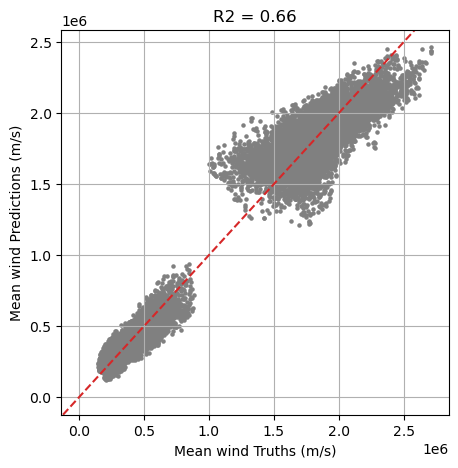

In [186]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val, y_val_predict, s=5, color='.5')
ax.grid()
ax.set_ylabel('Mean wind Predictions (m/s)')
ax.set_xlabel('Mean wind Truths (m/s)')
ax.axline((0,0), slope=1, color='tab:red', ls='--')
r2 = sklearn.metrics.r2_score(y_val,y_val_predict)
ax.set_title(f"R2 = {r2:.02f}")


## **QUESTION 7**: Did the preprocessing improve the prediction?

In [ ]:
...

Text(0.5, 1.0, 'R2 = 0.64')

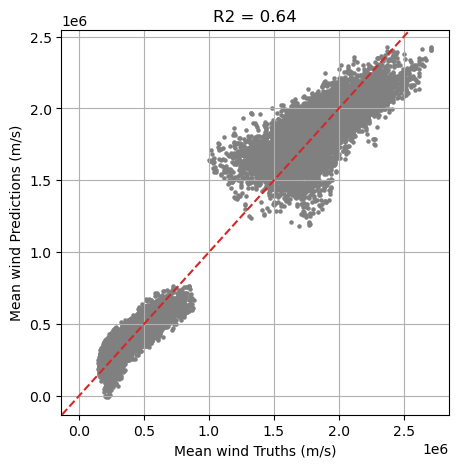

In [187]:
model_nopreprocess = LinearRegression()
model_nopreprocess.fit(X_train, y_train)
y_val_predict_nopreprocess = model_nopreprocess.predict(X_val)

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val, y_val_predict_nopreprocess, s=5, color='.5')
ax.grid()
ax.set_ylabel('Mean wind Predictions (m/s)')
ax.set_xlabel('Mean wind Truths (m/s)')
ax.axline((0,0), slope=1, color='tab:red', ls='--')
r2 = sklearn.metrics.r2_score(y_val,y_val_predict_nopreprocess)
ax.set_title(f"R2 = {r2:.02f}")
